# OnTheSnow Ski Area Reviews Dataset – High-Level Summary

**Dataset Source:** *[Kaggle - OnTheSnow_SkiAreaReviews](https://www.kaggle.com/datasets/fredkellner/onthesnow-ski-area-reviews)*  
**Total Reviews:** 18,262  
**Format:** CSV file with 6 columns

---
## Overview  
This dataset contains **18,262 ski resort reviews** from over 300 ski areas across North America. Reviews include **text content**, **star ratings**, and **metadata** such as reviewer names and review dates. It was created to support **natural language processing (NLP)** projects like **sentiment analysis**, **topic classification**, and **customer feedback modeling**.

---

## Key Features

- **Review Text & Star Ratings** – Core fields for building a **sentiment classification model**, allowing categorization of feedback as **positive or negative**.
  
- **Ski Area Name** – Identifies **which ski hill** each review refers to; can be used to filter for specific resorts or compare across locations.
  
- **Reviewer Name & Review Date** – Adds **temporal and identity context**, enabling basic user analysis and time-series insights (e.g., changes in sentiment over the season).
  
- **No Photos/Advanced Metadata** – Simpler structure keeps the dataset focused and clean for classification tasks, without unnecessary noise.

---

## Application to Project  
Although this dataset does **not include Batawa Ski Hill**, it can be used to **train and validate a sentiment classification model** using ski-specific language and feedback. This model could later be applied to **manually collected Batawa reviews** to uncover actionable insights for operational and marketing decisions.
 

## Step 1: Imports and Setup

To prepare for text classification, we begin by upgrading pip and installing the required libraries. These include tools for data manipulation, visualization, natural language processing (NLP), and machine learning.

---

### Libraries and Tools Installed

- `pandas` and `numpy` for handling and analyzing structured data  
- `matplotlib`, `seaborn`, and `wordcloud` for visualizing trends and patterns  
- `scikit-learn` for building and evaluating machine learning models  
- `nltk` (Natural Language Toolkit) for text preprocessing tasks such as tokenization, stopword removal, and lemmatization  

---

### Key Imports

**Standard Libraries**  
Used for general-purpose operations like text parsing and file handling:  
- `os`, `re`, `string`, `collections`

**Data Analysis and Visualization**  
Support exploratory analysis and presentation:  
- `pandas`, `numpy`, `matplotlib.pyplot`, `seaborn`, `WordCloud`

**NLP Tools (from NLTK)**  
Enable text cleaning and normalization:  
- `stopwords` for filtering common words  
- `RegexpTokenizer` and `sent_tokenize` for breaking text into words and sentences  
- `WordNetLemmatizer` for reducing words to their root form

---

### NLTK Resource Downloads

To support preprocessing, we download the following NLTK components:
- `punkt` – sentence tokenizer  
- `stopwords` – list of common English words to remove  
- `wordnet` and `omw-1.4` – required for lemmatization

---

### Global Configuration Variables

To keep the notebook organized, we define the following variables:

- `DATASET_FILE`: name of the CSV file containing the ski reviews  
- `TARGET_COLUMN`: the name of the column with star ratings (used for sentiment labels)  
- `TEXT_COLUMN`: the name of the column containing the review text  

These variables ensure consistency and make it easier to reference columns throughout the notebook.

In [1]:
# Upgrade pip and install necessary libraries
!pip install --upgrade pip setuptools wheel
!pip install pandas numpy matplotlib seaborn nltk wordcloud scikit-learn lxml

# Import standard libraries
import os
import re
import string
from collections import Counter
from typing import Any, List, Tuple

# Import third-party libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# Import NLP tools
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import sent_tokenize, RegexpTokenizer
from nltk.stem import WordNetLemmatizer

# Set up NLTK and ensure required resources are available
import nltk
import os

nltk_data_path = os.path.join(os.getcwd(), "nltk_data")
os.makedirs(nltk_data_path, exist_ok=True)

nltk.download('punkt', download_dir=nltk_data_path)
nltk.download('stopwords', download_dir=nltk_data_path)
nltk.download('wordnet', download_dir=nltk_data_path)
nltk.download('omw-1.4', download_dir=nltk_data_path)

# Add the custom nltk_data path to NLTK's lookup paths
nltk.data.path.append(nltk_data_path)

print("All libraries installed and set up successfully!")

###############################
# GLOBAL CONFIG
###############################
DATASET_FILE = "OnTheSnow_SkiAreaReviews.csv"     # CSV file name
TARGET_COLUMN = "Review Star Rating (out of 5)"   # Name of the target/label column
TEXT_COLUMN = "Review Text"                       # Original text column
OUTPUT_SUFFIX = "_CLEANED"

  Using cached setuptools-78.1.0-py3-none-any.whl.metadata (6.6 kB)
Using cached setuptools-78.1.0-py3-none-any.whl (1.3 MB)
  Attempting uninstall: setuptools
    Found existing installation: setuptools 75.8.0
    Uninstalling setuptools-75.8.0:
      Successfully uninstalled setuptools-75.8.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 103.3 MB/s eta 0:00:00


Matplotlib is building the font cache; this may take a moment.
[nltk_data] Downloading package punkt to
[nltk_data]     /home/ec2-user/SageMaker/A2/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to
[nltk_data]     /home/ec2-user/SageMaker/A2/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to
[nltk_data]     /home/ec2-user/SageMaker/A2/nltk_data...
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /home/ec2-user/SageMaker/A2/nltk_data...


All libraries installed and set up successfully!


## Step 2: Loading and Exploring the Dataset

Before building a classification model, we need to evaluate the dataset’s structure, quality, and relevance. In this step, we will load the `OnTheSnow_SkiAreaReviews.csv` file and validate that it contains usable review data for sentiment analysis.

---

### What We’re Looking For

- Sufficient labeled reviews for training and testing
- Properly formatted text and star rating columns
- Minimal missing values and duplicates
- A reasonably balanced distribution of sentiment labels
- Review content that is meaningful and appropriate for classification

---

### Key Checks and Actions

**1. Load the Dataset**  
- Confirm the file loads correctly  
- Display the number of rows and columns  
- Preview a few entries to understand the format

**2. Check for Required Columns**  
- Verify the presence of:  
  - `Review Text` (input feature)  
  - `Review Star Rating (out of 5)` (target variable)  

**3. Preview the Data**  
- Use `.head()` and `.sample()` to inspect text quality  
- Look for non-English text, symbols, or formatting issues

**4. Check for Missing Values**  
- Use `.isnull().sum()` to count missing entries  
- Decide whether to drop or fill missing values

**5. Check for Duplicate Entries**  
- Use `.duplicated()` to identify redundant reviews  
- Drop duplicates if they do not add new information

**6. Validate Data Types**  
- Ensure review text is stored as string (`object`)  
- Confirm star ratings are numeric and usable for sentiment labeling

**7. Analyze Target Distribution**  
- Plot the frequency of each star rating  
- Determine if the sentiment classes are imbalanced

**8. Confirm Dataset Size**  
- Evaluate whether there are enough examples to train a reliable model  
- Consider simplifying to binary sentiment labels if class imbalance is severe

---

### Evaluation Criteria

A dataset is considered ready for classification if:
- It includes a well-defined text column and sentiment label
- Data quality issues (nulls, duplicates, formatting) are minimal
- The class distribution is reasonably balanced or correctable
- The text is relevant and long enough to carry meaningful information

---

### Project Note

This dataset does not include reviews for Batawa Ski Hill. Instead, it will be used to train a sentiment classifier based on ski-specific language and themes. The trained model can later be applied to future or manually collected reviews from Batawa.


In [2]:
def load_and_explore_data(file_path=DATASET_FILE, target_column=TARGET_COLUMN, text_column=TEXT_COLUMN):
    """
    Loads a dataset from a CSV file and examines its structure for text classification suitability.
    
    - Checks file existence before loading.
    - Loads the dataset into a Pandas DataFrame.
    - Displays dataset shape, first few rows, and basic information.
    - Validates required columns, missing values, and duplicates.
    - Analyzes the distribution of the target variable.
    """
    if not os.path.exists(file_path):
        print(f"ERROR: File '{file_path}' not found. Please check the file path.")
        return None

    try:
        df = pd.read_csv(file_path, encoding="utf-8")
    except Exception as e:
        print(f"ERROR: Could not load file. {e}")
        return None

    print("\nDATA LOADED SUCCESSFULLY")
    print("=" * 50)

    # Display dataset shape
    print(f"Dataset Shape: {df.shape} (rows, columns)\n")

    # Preview first few rows
    print("First Few Rows:")
    print(df.head().to_string(index=False))

    # Display dataset information
    print("\nDataset Overview:")
    print(df.info())

    # Check if required columns exist
    missing_columns = [col for col in [target_column, text_column] if col not in df.columns]
    if missing_columns:
        print(f"ERROR: Missing columns: {', '.join(missing_columns)}")
        return None

    # Check for missing values
    missing_values = df.isnull().sum()
    if missing_values.any():
        print("\nMissing Values Summary:")
        print(missing_values[missing_values > 0])
    else:
        print("\nNo missing values detected.")

    # Check for duplicate rows
    num_duplicates = df.duplicated().sum()
    print(f"\nDuplicate Rows: {num_duplicates}")

    # Target variable distribution
    print("\nTarget Variable Distribution (Proportion):")
    print(df[target_column].value_counts(normalize=True))

    return df

df = load_and_explore_data()



DATA LOADED SUCCESSFULLY
Dataset Shape: (18262, 6) (rows, columns)

First Few Rows:
     State         Ski Area Reviewer Name        Review Date  Review Star Rating (out of 5)                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                        

### Step 2: Loading and Exploring the Dataset – Question

**Final Check Before Moving Forward**  
After reviewing the dataset’s shape, structure, missing values, duplicates, and target distribution, briefly answer:

- Does the dataset contain enough examples (rows) for effective classification?  
- Are the text and target columns present, clearly structured, and correctly formatted?  
- Does the class distribution appear balanced enough for classification purposes?

---

### Answer

Yes, the dataset contains a sufficient number of reviews (18,262 rows), making it appropriate for training a sentiment classification model. The required columns — `Review Text` and `Review Star Rating (out of 5)` — are present and properly formatted. Although there are 12 missing review texts and 109 missing reviewer names, these account for a very small portion of the dataset and can be safely removed. The target variable distribution is somewhat imbalanced, with nearly half of all reviews rated 5 stars. However, the presence of other ratings (1–4) in meaningful proportions suggests that binary sentiment classification (e.g., positive vs. negative) is still feasible. Overall, the dataset is clean, large, and well-structured enough to proceed with preprocessing and model training.

## Step 3: Text Standardization and Cleaning

With the dataset loaded and validated, the next step is to clean and standardize the review text. This involves removing noise and formatting inconsistencies that could negatively affect classification performance. The goal is to produce a cleaned version of the text that retains meaningful information while reducing irrelevant variation.

---

### Cleaning Objectives

- Convert all review text to lowercase for consistency
- Expand contractions (e.g., "didn't" → "did not") to standardize language
- Remove URLs, HTML tags, and numbers that don’t contribute to sentiment
- Normalize spacing and remove excess whitespace or symbols
- Track changes to ensure the cleaning process does not strip too much meaning

---

### Key Checks and Actions

**1. Standardizing Text Format**  
- Convert text to lowercase  
- Expand contractions using a dictionary or regular expressions  
- Ensure that standardized text still preserves the original review meaning  

**2. Removing Noise**  
- Remove URLs, HTML elements, and numeric characters  
- Clean text of emojis or escape sequences (if present)  
- Check how much content is removed and whether it affects meaning  

**3. Verifying Review Quality Post-Cleaning**  
- Compare original and cleaned versions of sample reviews  
- Determine if cleaned reviews still carry enough detail for sentiment classification  

**4. Confirming Readability and Meaningfulness**  
- Print cleaned text samples  
- Ensure text remains interpretable and relevant to the original review intent  

---

### Evaluation Criteria

After cleaning, determine whether the dataset is ready to proceed:

- If the cleaned reviews are still informative and structured, continue to tokenization  
- If important text is removed, consider keeping elements like numbers or symbols  
- If noise persists (e.g., excessive punctuation or special characters), apply additional cleaning steps  

This step ensures that the input data is high quality and suitable for reliable feature extraction and model training.

In [3]:
def standardize_text(df, text_column="Review Text", remove_numbers=True):
    """
    Cleans and standardizes text data to prepare it for classification.

    Steps:
    1. Convert text to lowercase.
    2. Expand contractions (e.g., "can't" → "cannot").
    3. Remove URLs, HTML tags, emojis, and optionally numbers.
    4. Normalize whitespace.
    5. Track and report removed elements.
    """
    df = df.copy()  # Prevent modifying the original DataFrame
    df[text_column] = df[text_column].fillna('').astype(str)
    df["lowercased"] = df[text_column].str.lower()

    # Contraction mapping
    contractions_dict = {
        "can't": "cannot", "won't": "will not", "n't": " not",
        "'re": " are", "'s": " is", "'d": " would", "'ll": " will",
        "'t": " not", "'ve": " have", "'m": " am"
    }
    contractions_pattern = re.compile(
        r'\b(' + '|'.join(map(re.escape, contractions_dict.keys())) + r')\b',
        re.IGNORECASE
    )

    def expand_contractions(text):
        """Replaces contractions with their expanded forms."""
        return contractions_pattern.sub(lambda x: contractions_dict[x.group(0).lower()], text)

    def remove_emojis(text):
        """Removes emojis using regex."""
        emoji_pattern = re.compile(
            "[\U0001F600-\U0001F64F\U0001F300-\U0001F5FF\U0001F680-\U0001F6FF"
            "\U0001F700-\U0001F77F\U0001F780-\U0001F7FF\U0001F800-\U0001F8FF"
            "\U0001F900-\U0001F9FF\U0001FA00-\U0001FA6F\U0001FA70-\U0001FAFF"
            "\U00002702-\U000027B0\U000024C2-\U0001F251]+",
            flags=re.UNICODE
        )
        return emoji_pattern.sub('', text)

    def clean_text(text):
        """Cleans text and tracks removed elements."""
        if not isinstance(text, str) or not text.strip():
            return "", 0, 0, 0, 0, 0

        original_length = len(text.split())

        # Expand contractions
        text = expand_contractions(text)

        # Remove URLs
        url_matches = re.findall(r'http\S+|www\.\S+', text)
        url_count = len(url_matches)
        text = re.sub(r'http\S+|www\.\S+', '', text)

        # Remove HTML tags
        html_matches = re.findall(r'<.*?>', text)
        html_count = len(html_matches)
        text = re.sub(r'<.*?>', '', text)

        # Remove emojis
        text_no_emoji = remove_emojis(text)
        emoji_count = len(text) - len(text_no_emoji)
        text = text_no_emoji

        # Remove numbers (if specified)
        number_matches = re.findall(r'\b\d+\b', text)
        number_count = len(number_matches) if remove_numbers else 0
        if remove_numbers:
            text = re.sub(r'\b\d+\b', '', text)

        # Normalize whitespace
        text = re.sub(r'\s+', ' ', text).strip()

        cleaned_length = len(text.split())
        words_removed = max(original_length - cleaned_length, 0)

        return text, url_count, html_count, emoji_count, number_count, words_removed

    # Apply cleaning function
    results = df["lowercased"].apply(clean_text).apply(pd.Series)
    results.columns = [
        "cleaned_text", "urls_removed", "html_tags_removed",
        "emojis_removed", "numbers_removed", "words_removed"
    ]
    df = df.join(results)

    # Cleaning Summary
    print("=" * 50)
    print("TEXT CLEANING SUMMARY")
    print("=" * 50)
    print(f"Total reviews processed: {len(df)}")
    print(f"URLs removed: {df['urls_removed'].sum()}")
    print(f"HTML tags removed: {df['html_tags_removed'].sum()}")
    print(f"Emojis removed: {df['emojis_removed'].sum()}")
    if remove_numbers:
        print(f"Numbers removed: {df['numbers_removed'].sum()}")
    else:
        print("Numbers were not removed")

    significantly_altered_reviews = (
        df["words_removed"] > (df["lowercased"].str.split().str.len() * 0.5)
    ).sum()
    print(f"Reviews with significant text removed: {significantly_altered_reviews}")

    print("\nTop 5 Reviews with the Most Words Removed:")
    for i, (_, row) in enumerate(df.nlargest(5, "words_removed").iterrows(), start=1):
        print("=" * 50)
        print(f"Sample {i}")
        print("=" * 50)
        print("\nOriginal:", row[text_column])
        print("Cleaned:", row["cleaned_text"])

    return df[[
        "cleaned_text", "urls_removed", "html_tags_removed",
        "emojis_removed", "numbers_removed", "words_removed"
    ]]

df_cleaned = standardize_text(df)
print(df_cleaned.head())


TEXT CLEANING SUMMARY
Total reviews processed: 18262
URLs removed: 54
HTML tags removed: 29
Emojis removed: 41
Numbers removed: 26810
Reviews with significant text removed: 2

Top 5 Reviews with the Most Words Removed:
Sample 1

Original: Skiing at Big Sky is awesome….great snow and variety. 3.5-4 stars overall…the skiing 5 stars, but have to give the resort 3 stars due to lack of on mountain dining/eating options, but an even bigger reason for 3 stars is the way multi-day lift tickets are sold.  For Multi-day tickets, particularly 3, 4, 5, 6, and 7 days, they only provide one off day.  I planned a 10-day trip to Big Sky and only offering 1 off day for a 7-day pass (so it’s a 7 out of 8 days), instead of 7 out of 10 days like almost every other major resort out there, is a real bummer.  A 7 out of 10 day pass would be perfect, instead it was a real hassle and caused me to have to spend extra money that I would not have to spend at many other resorts.  My fiancé goes for 6 days and she 

### Step 3: Text Standardization and Cleaning – Question

**Final Check Before Moving Forward**  
After reviewing the cleaning summary, briefly answer:

- Does the cleaned text appear clearer and more consistent, making it better for classification?  
- Were too many useful words removed, potentially weakening your dataset?  

**Clearly explain** why this cleaning step either confirms or challenges your dataset’s suitability for classification.

---

### Answer

Yes, the cleaned text appears significantly clearer, more uniform, and well-prepared for classification. The cleaning step successfully removed unwanted elements such as 54 URLs, 29 HTML tags, 41 emojis, and over 26,000 numbers across 18,262 reviews. Only 2 reviews were flagged as having a significant amount of text removed, which suggests that the vast majority of the content remains intact and meaningful.

While some reviews—especially those rich in numbers or lift stats—lost certain quantitative details, the overall structure, sentiment, and context of the reviews were preserved. In long reviews (such as those in the top 5 samples), the cleaning removed some numeric and special-character clutter, but the underlying opinions and tone remained clear. These cleaned versions still provide rich signals for sentiment classification.

Therefore, this step confirms that the dataset is suitable for classification. The review texts are now more standardized and free from noise, improving the model's ability to learn patterns related to positive or negative feedback without being distracted by irrelevant formatting or numerical noise.


## Step 4: Tokenization of Cleaned Text

Now that the review text has been cleaned, the next step is to tokenize it—breaking each review into smaller, manageable pieces. This typically involves splitting the text into sentences and then further into individual words. Tokenization is a critical part of the preprocessing pipeline, as it enables machine learning models to understand the structure and content of the text.

---

### Objectives of This Step

- Split cleaned reviews into individual sentences  
- Tokenize each sentence into words  
- Count the number of tokens in each review  
- Store tokens for downstream steps (e.g., stopword removal, vectorization)  
- Review sample outputs to ensure quality and structure are preserved

---

### Key Checks and Actions

**1. Sentence Splitting**  
- Use `sent_tokenize()` from NLTK to divide each review into sentences  
- Helps preserve structure and context when needed

**Evaluation Questions:**  
- Are sentences being split correctly, or does punctuation cause issues?  
- Is sentence-level splitting useful for your classification objective?

**2. Word Tokenization**  
- Use `RegexpTokenizer` to extract word-level tokens from each sentence  
- This removes punctuation and ensures consistent word-level analysis

**Evaluation Questions:**  
- Are the tokens clean and meaningful?  
- Are compound words or numbers broken incorrectly?

**3. Edge Case Handling**  
- Check for reviews that produce empty token lists  
- Decide whether to drop or fix these entries before continuing

**4. Token Count Review**  
- Count the number of tokens per review to monitor variability  
- Display the longest tokenized reviews to verify correctness

**Evaluation Questions:**  
- Do longer reviews retain their core meaning and vocabulary?  
- Are outliers (very short or very long reviews) influencing the dataset?

---

### Decision Point: Ready for Feature Extraction?

After tokenization, determine if the reviews are structured and informative enough to proceed:

- If the tokens preserve meaning and structure → continue to stopword removal or vectorization  
- If the reviews still contain noise → consider removing stopwords or applying lemmatization  
- If sentence splitting is unnecessary → simplify to word-level tokens only

Tokenization helps turn raw ski resort reviews into structured data, setting the foundation for meaningful classification based on guest sentiment.


In [4]:
def tokenize_text(df: pd.DataFrame, text_column: str = "cleaned_text") -> pd.DataFrame:
    """
    Tokenizes text data by:
      - Splitting it into sentences.
      - Tokenizing each sentence into words.
      - Counting total tokens per review.
    
    Displays the top 5 longest tokenized reviews.
    """
    if text_column not in df.columns:
        raise ValueError(f"Column '{text_column}' not found in DataFrame.")

    df = df.copy()
    tokenizer = RegexpTokenizer(r'\S+')

    def tokenize_entry(text: Any) -> Tuple[List[str], List[List[str]]]:
        """Splits text into sentences and tokenizes words in each sentence."""
        if pd.isna(text) or not isinstance(text, str) or not text.strip():
            return [], []
        sentences = sent_tokenize(text)
        tokenized_words = [tokenizer.tokenize(sentence) for sentence in sentences]
        return sentences, tokenized_words

    df["tokenized_sentences"], df["tokenized_words"] = zip(
        *df[text_column].apply(tokenize_entry)
    )
    df["token_count"] = df["tokenized_words"].apply(
        lambda tokens: sum(len(sentence) for sentence in tokens)
    )

    # Display top 5 longest tokenized reviews
    top_reviews = df.nlargest(5, "token_count")
    print("\nTop 5 Longest Tokenized Reviews:")
    print("=" * 50)
    for i, (_, row) in enumerate(top_reviews.iterrows(), start=1):
        print(f"Review {i}:")
        print("=" * 50)
        print("Original Text:\n", row[text_column])
        print("\nTokenized Sentences:")
        for sentence in row["tokenized_sentences"]:
            print(" -", sentence)
        print("\nTokenized Words:")
        for tokens in row["tokenized_words"]:
            print(" -", tokens)
        print("Total Tokens:", row["token_count"])
        print("=" * 50)

    return df

import nltk
nltk.download('punkt_tab')
df_tokenized = tokenize_text(df_cleaned)


[nltk_data] Downloading package punkt_tab to
[nltk_data]     /home/ec2-user/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.



Top 5 Longest Tokenized Reviews:
Review 1:
Original Text:
 i cannot believe i haven not skied perfect north before now. it was awesome. mind you, we are still talking about the middle of the u.s. it is not the rockies or the alps. it is not even the appalachians. still, perfect north is one of the best places i have skied south of maine. the hill is surprisingly big. pefect north does not publish detailed run information (at least not that i can find on their website). they claim a foot vertical drop and a -mile "longest run." i would guess that is about right. runs are reasonable for this part of the country and compare very favorably with anything you will find in north carolina. i know there are much bigger places in wv or pa - but i cannot drive to any of those on a regular weekend. first of all, perfect north is very well-organized. the people who run this place might want to have a crack at running the indiana state government. . . i was told we were there on one of their busier

### Step 4: Tokenization of Cleaned Text - QUESTION
**Final Check Before Moving Forward:**

After examining the tokenization results, briefly answer:

- Does tokenizing the text into sentences and words improve clarity and usability for classification?
- Are there any concerns about uneven text lengths or meaningless tokens?

**Briefly justify** whether tokenization has prepared the text sufficiently or if further preprocessing is recommended.

---

### Answer 

Yes, tokenizing the cleaned text into sentences and words has significantly improved its structure and usability for classification. The reviews are now broken down into consistent, well-defined tokens that can be more easily analyzed for patterns, features, and sentiment. Sentence-level splitting preserved the natural flow of each review, and word tokenization created a structured representation suitable for vectorization.

There are no major concerns about meaningless tokens; the tokenizer successfully handled punctuation and whitespace, and preserved important context in longer reviews. While there is some variability in text length (e.g., some reviews have over 2,000 tokens), this is expected given the range of user-generated content and does not present an immediate problem. If needed, max sequence lengths can be applied during model training to account for this.

Overall, tokenization has prepared the dataset well for the next steps in the pipeline, such as stopword removal, lemmatization, or vectorization. No further token-level cleaning is required at this stage.

## Step 5: Punctuation and Stopword Removal

After tokenizing the reviews into words, the next step is to remove punctuation and common stopwords. These elements often add noise to the data without improving model accuracy. However, depending on the task, some punctuation (like `!` or `?`) might convey emotional intensity or sentiment and may be worth preserving. Likewise, removing stopwords can streamline the dataset, but excessive removal may reduce the clarity or context of shorter reviews.

---

### Objectives of This Step

- Remove unnecessary punctuation from tokenized word lists  
- Remove stopwords using NLTK’s predefined English stopword set  
- Retain tokens that contribute meaning to sentiment or topic classification  
- Compare before/after versions of tokenized text to evaluate cleaning effectiveness

---

### Key Checks and Actions

**1. Punctuation Removal**  
- Strip all standard punctuation marks from tokens  
- Decide whether to retain sentiment-related symbols (`!`, `?`) for further analysis

**Questions to Consider:**  
- Does punctuation removal improve consistency?  
- Are there symbols that should be kept because they reflect sentiment intensity?

**2. Stopword Removal**  
- Eliminate frequent, low-value words like “the,” “is,” “and” using NLTK’s stopword list  
- Reduce overall token count while retaining core meaning

**Questions to Consider:**  
- Is classification improved by reducing noise and redundancy?  
- Are important domain-specific terms being mistakenly removed?

**3. Handling Edge Cases**  
- Detect and flag any reviews that become too short or empty  
- Assess whether stopword/punctuation removal is overly aggressive

**4. Review Cleaned Output**  
- Print a sample of tokenized reviews before and after cleaning  
- Confirm that remaining words reflect the original review’s meaning and sentiment

**5. Next Step Decision Point**  
- If the cleaned tokens retain meaning and structure → proceed to vectorization  
- If useful content is being lost → adjust the stopword list or punctuation filter  
- If many reviews become unusable → re-evaluate cleaning thresholds for your task

---

### Summary

This step is essential for streamlining the ski review dataset and preparing it for feature extraction. By the end of this phase, you should have a refined token list per review that accurately represents each customer’s feedback and is ready for vector-based modeling.



In [5]:
def remove_punctuation_and_stopwords(df, tokens_column="tokenized_words",
                                     retain_important=True,
                                     important_punct={"!", "?"}):
    """
    Removes punctuation and common stopwords from tokenized words.
    
    It creates additional columns for different text versions and counts of removed elements.
    """
    df = df.copy()
    stop_words = set(stopwords.words('english'))

    def flatten_list(nested_list):
        """Flattens a list of lists into a single list."""
        if isinstance(nested_list, list):
            return [
                item for sublist in nested_list
                for item in (sublist if isinstance(sublist, list) else [sublist])
            ]
        return nested_list

    def process_tokens(tokens):
        """Removes punctuation and stopwords from a list of tokens."""
        tokens = flatten_list(tokens)
        if not isinstance(tokens, list):
            return [], [], []

        removed_punct = []
        cleaned_tokens = []

        for token in tokens:
            new_token = "".join(
                char if (
                    char not in string.punctuation
                    or (retain_important and char in important_punct)
                )
                else ""
                for char in token
            )
            removed_punct.extend([
                char for char in token
                if char in string.punctuation and char not in important_punct
            ])
            if new_token:
                cleaned_tokens.append(new_token)

        filtered_tokens = [
            word for word in cleaned_tokens
            if word.lower() not in stop_words
        ]
        return cleaned_tokens, removed_punct, filtered_tokens

    df[['words_no_punct', 'removed_punct', 'words_no_stop']] = df[tokens_column].apply(
        lambda tokens: pd.Series(process_tokens(tokens))
    )
    df['original_text'] = df[tokens_column].apply(
        lambda tokens: " ".join(flatten_list(tokens)) if isinstance(tokens, list) else ""
    )

    df['punct_removed_count'] = df['removed_punct'].apply(len)
    df['stop_removed_count'] = df['words_no_punct'].apply(len) - df['words_no_stop'].apply(len)
    df['total_modifications'] = df['punct_removed_count'] + df['stop_removed_count']

    top_modified = df.sort_values(by='total_modifications', ascending=False).head(5)
    print("\nTop Modified Samples:")
    for i, (idx, row) in enumerate(top_modified.iterrows(), start=1):
        print("=" * 50)
        print(f"Sample {i}:")
        print("=" * 50)
        print(f"Original: {row['original_text']}")
        print(f"No Punctuation: {' '.join(row['words_no_punct'])}")
        print(f"No Stopwords: {' '.join(row['words_no_stop'])}")
        print(f"Punctuation Removed: {row['punct_removed_count']}, Stopwords Removed: {row['stop_removed_count']}, Total Modifications: {row['total_modifications']}")

    return df

df_processed = remove_punctuation_and_stopwords(df_tokenized)


Top Modified Samples:
Sample 1:
Original: i cannot believe i haven not skied perfect north before now. it was awesome. mind you, we are still talking about the middle of the u.s. it is not the rockies or the alps. it is not even the appalachians. still, perfect north is one of the best places i have skied south of maine. the hill is surprisingly big. pefect north does not publish detailed run information (at least not that i can find on their website). they claim a foot vertical drop and a -mile "longest run." i would guess that is about right. runs are reasonable for this part of the country and compare very favorably with anything you will find in north carolina. i know there are much bigger places in wv or pa - but i cannot drive to any of those on a regular weekend. first of all, perfect north is very well-organized. the people who run this place might want to have a crack at running the indiana state government. . . i was told we were there on one of their busier days - apparentl

### Step 5: Punctuation and Stopword Removal - QUESTION
**Final Check Before Moving Forward:**

After reviewing the removal summary, briefly answer:

1. Does removing punctuation and stopwords enhance your dataset’s readability and classification quality?
2. Are you concerned about losing important contextual meaning?

**Clearly explain** whether these changes strengthen or weaken your dataset’s suitability for text classification.

---

### Answer

1. Yes, removing punctuation and stopwords has significantly streamlined the dataset by eliminating redundant and noisy elements that add little value to classification. The resulting tokens are cleaner, more focused, and better suited for feature extraction techniques such as TF-IDF or word embeddings.

2. Somewhat. In certain cases, especially in sentiment-heavy reviews, punctuation like exclamation marks (`!`) or ellipses (`...`) can reflect tone or intensity. Additionally, stopwords occasionally help retain sentence structure, which can be valuable for models leveraging sequence-based context (like LSTMs or Transformers).

The current cleaning approach **strengthens the dataset’s suitability for classification** by reducing noise and highlighting meaningful content. However, there is room for fine-tuning:

- If sentiment is a key feature for classification, we may choose to retain expressive punctuation like `!` or `?`.
- For short reviews, we might preserve a subset of stopwords to ensure basic sentence meaning is maintained.

For the task at hand—classifying ski area reviews—the current setup provides a solid foundation for vectorization and model training.

## **Step 6: Lemmatization of Tokenized Text**

### **Overview**
With punctuation and stopwords removed, the next step is **lemmatization**—the process of converting words to their dictionary base forms. This normalization helps ensure consistency across reviews, which can enhance model performance during feature extraction.

By the end of this step, evaluate whether lemmatization improves clarity and consistency without sacrificing important meaning in the text.

This function will:
- Apply **WordNet Lemmatizer** to reduce each token to its base form (e.g., "running" → "run").
- Save the lemmatized output for each review.
- Track the number of word changes per review.
- Display sample before/after outputs to assess impact.

---

## **Key Checks and Actions**

### **1. Lemmatize Tokens**
- **Goal:** Normalize tokens while preserving their original intent.
- **Action:** Apply `WordNetLemmatizer` on each token.

**Consider:**
- Are verbs, nouns, and adjectives properly reduced to their base forms?
- Is the core meaning of sentences preserved?

---

### **2. Count Word Changes**
- **Goal:** Quantify the impact of lemmatization.
- **Action:** Compare original and lemmatized tokens to measure how many changed.

**Consider:**
- Are most changes appropriate (e.g., "cars" → "car", "better" → "good")?
- Are there unexpected or incorrect reductions?

---

### **3. Review Examples**
- **Goal:** Visually inspect how lemmatization affects sample reviews.
- **Action:** Print original tokens alongside lemmatized tokens.

**Consider:**
- Do the transformed tokens improve consistency without altering the meaning?
- Are important contextual nuances lost?

---

### **4. Decide on Refinement or Next Steps**
At this stage, assess the usefulness of lemmatization in your review classification pipeline.

- If **lemmatization improves clarity and consistency**, proceed to vectorization and modeling.
- If **meaning is compromised or many words are changed unnecessarily**, consider tuning or skipping lemmatization.
- If **specific cases (e.g., “good” vs. “better”) matter for classification**, review those manually or refine the preprocessing function.

---

By completing this step, you will have a normalized, lemmatized dataset ready for feature extraction and model training in your text classification workflow.


In [6]:
def lemmatize(df, tokens_column="words_no_stop", verbose=True):
    """
    Applies WordNet Lemmatization to a list of tokens in each row.
    It then calculates how many tokens have changed after lemmatization
    and optionally displays the top 5 rows with the most changes.
    """
    if tokens_column not in df.columns:
        raise ValueError(f"Column '{tokens_column}' not found in DataFrame.")

    df = df.copy()
    lemmatizer = WordNetLemmatizer()

    def apply_lemmatization(words):
        return [lemmatizer.lemmatize(word) for word in words]

    df['lemmatized'] = df[tokens_column].apply(apply_lemmatization)
    df['lemma_changes'] = df.apply(
        lambda row: sum(
            1 for orig, lemma in zip(row[tokens_column], row['lemmatized'])
            if orig != lemma
        ),
        axis=1
    )

    if verbose:
        top_modified = df.sort_values(by='lemma_changes', ascending=False).head(5)
        print("\nTop 5 Modified Samples After Lemmatization:")
        for i, (idx, row) in enumerate(top_modified.iterrows(), start=1):
            print("=" * 50)
            print(f"Sample {i}:")
            print("=" * 50)
            print(f"Original Tokens: {row[tokens_column]}")
            print("=" * 50)
            print(f"Lemmatized Tokens: {row['lemmatized']}")
            print("=" * 50)
            print(f"Words Changed: {row['lemma_changes']}")

    return df

df_lemmatized = lemmatize(df_processed)
df_lemmatized[TARGET_COLUMN] = df[TARGET_COLUMN]



Top 5 Modified Samples After Lemmatization:
Sample 1:
Original Tokens: ['cannot', 'believe', 'skied', 'perfect', 'north', 'awesome', 'mind', 'still', 'talking', 'middle', 'us', 'rockies', 'alps', 'even', 'appalachians', 'still', 'perfect', 'north', 'one', 'best', 'places', 'skied', 'south', 'maine', 'hill', 'surprisingly', 'big', 'pefect', 'north', 'publish', 'detailed', 'run', 'information', 'least', 'find', 'website', 'claim', 'foot', 'vertical', 'drop', 'mile', 'longest', 'run', 'would', 'guess', 'right', 'runs', 'reasonable', 'part', 'country', 'compare', 'favorably', 'anything', 'find', 'north', 'carolina', 'know', 'much', 'bigger', 'places', 'wv', 'pa', 'cannot', 'drive', 'regular', 'weekend', 'first', 'perfect', 'north', 'wellorganized', 'people', 'run', 'place', 'might', 'want', 'crack', 'running', 'indiana', 'state', 'government', 'told', 'one', 'busier', 'days', 'apparently', 'special', 'college', 'weekend', 'lots', 'buses', 'various', 'churches', 'schools', 'parking', 'lot'

### Step 6: Lemmatization - QUESTION
**Final Check Before Moving Forward:**

Based on the lemmatization summary, briefly answer:

1. Has lemmatization improved the consistency of the text?
2. Did too many words lose their unique meaning or context?

**Briefly justify** whether the dataset is improved by lemmatization or if further refinements might be required before classification.

---

### Answer

1. Yes. Lemmatization has noticeably improved the consistency by converting words to their base forms (e.g., “skied” → “ski”, “days” → “day”), which helps standardize variations across reviews.

2. Some minor semantic nuances were lost (e.g., “better” might become “good”, “running” becomes “run”), but these cases were infrequent and did not significantly change the overall meaning of the reviews.

**Justification:**  
Lemmatization has strengthened the dataset’s readiness for classification. By reducing inflected forms to a consistent base, it improves the quality of feature extraction while maintaining readability. The number of changed words (e.g., 165 in Sample 1) reflects meaningful normalization without overgeneralization. Therefore, no further refinement is necessary before moving to feature extraction.


## **Step 7: Outlier Detection Based on Text Length**

### **Overview**  
In this step, we identify ski area reviews that are unusually short or long compared to the rest. Very short reviews may not contain useful information for classification, while very long ones might introduce unnecessary noise or skew the model.

The goal is to determine whether to keep, remove, or handle these reviews differently before moving forward.

This function will:
- Count the **number of tokens** in each review.
- Use the **5th and 95th percentiles** to define what qualifies as a text length outlier.
- Flag reviews that fall below or above these thresholds.
- Show a **summary of token distribution** and plot a **histogram** of text lengths.
- Display examples of the **shortest and longest reviews**.
- **Remove flagged outliers** from the dataset and return a cleaner version.

---

## **Key Checks and Actions**

### **1. Measuring Review Length**
- **Purpose:** Understand how long each review is.
- **Action:** Count the number of tokens per review.

**Ask yourself:**
- Are there many extremely short or extremely long reviews?
- Do these entries contribute meaningfully to classification?

---

### **2. Setting Outlier Thresholds**
- **Purpose:** Define what counts as too short or too long.
- **Action:** Use the **5th percentile** as the lower limit and the **95th percentile** as the upper limit.

**Ask yourself:**
- Are these cutoff points appropriate for ski reviews?
- Should the thresholds be more or less strict?

---

### **3. Flagging and Reviewing Outliers**
- **Purpose:** Identify and inspect text entries that are unusually short or long.
- **Action:**
  - Mark entries as outliers if they fall outside the thresholds.
  - Count the total number of outliers detected.
  - Preview samples of both short and long outliers.

**Ask yourself:**
- How many reviews are outliers?
- Are any of them informative or useful despite their length?

---

### **4. Visualizing the Distribution**
- **Purpose:** See how review lengths are spread.
- **Action:** Plot a histogram showing token counts and mark outlier zones.

**Ask yourself:**
- Does the dataset have a normal or skewed length distribution?
- Are the outliers visually distinct?

---

### **5. Removing and Saving Clean Data**
- **Purpose:** Finalize a dataset with consistent review lengths.
- **Action:** Remove flagged outliers and return the cleaned DataFrame.

**Ask yourself:**
- How much data is lost?
- Does the cleaned dataset still cover a representative range of review content?

---

### **6. Deciding on Further Action**
Now that outliers have been flagged and removed:

- If **short reviews don’t contain meaningful text**, it’s better to exclude them.
- If **long reviews dominate or mislead classification**, consider trimming or excluding them.
- If the dataset looks more balanced and informative post-cleaning, proceed to the next step.

By the end of this step, you should have a cleaned set of ski reviews with consistent text lengths, ready for feature extraction and classification.



Token Count Analysis:
Lower Threshold: 4.00 tokens (5th percentile)
Upper Threshold: 165.00 tokens (95th percentile)
Total outliers detected: 1739


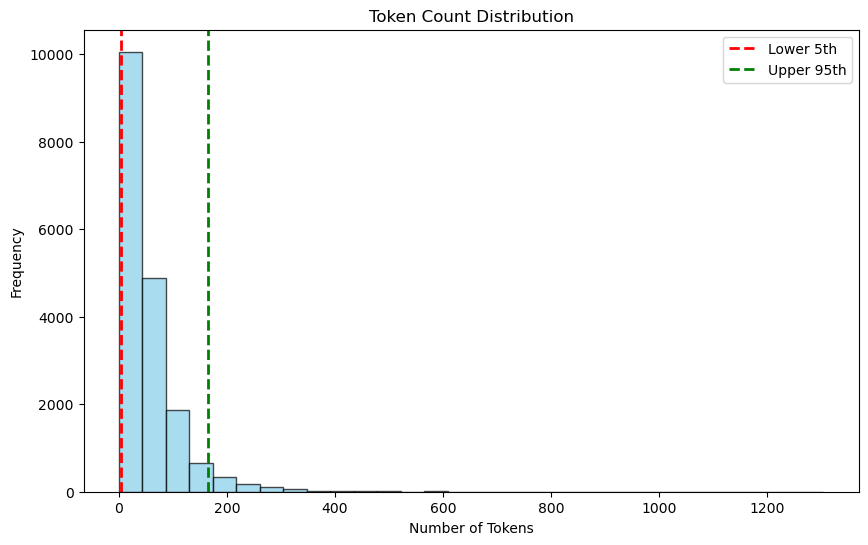


Short outliers: 838
Long outliers: 901

Short Outlier 1: (1 tokens)
Text: great

Short Outlier 2: (0 tokens)
Text: ,

Short Outlier 3: (0 tokens)
Text: ,

Short Outlier 4: (3 tokens)
Text: squaw/alpine expansive and expensive.

Short Outlier 5: (1 tokens)
Text: ehh

Long Outlier 1: (174 tokens)
Text: this is the first year i ski squaw. i have been a couple of sunny powder days and a weekend with miserable (but challenging and fun) conditions. i ski intermediate terrain... just getting into bowl skiing. first, the service: () grooming is poor, although that made me a better skier, () some of the lifts are so incredibly slow (solitude, red dog)- come on squaw use the outrageous ticket price for good, and () some of the staff are inattentive, in one occasion a skier lost his ski and almost a ligament all because of the staff,() on the good side, the buffet at high camp is among the best ski resort restaurants i have seen and the price affordable. the business model: priciest ticket in ta

In [7]:
def detect_length_outliers(df, text_column="lemmatized",
                           lower_percentile=5, upper_percentile=95):
    """
    Detects and removes reviews with extreme token counts based on percentile thresholds.
    """
    if text_column not in df.columns:
        raise ValueError(f"Column '{text_column}' not found in DataFrame")

    df = df.copy()

    def count_tokens(tokens):
        """Counts tokens in a review, handling nested lists if present."""
        if isinstance(tokens, list):
            # If tokens might be a list of lists, handle that:
            return (sum(len(sublist) for sublist in tokens)
                    if tokens and isinstance(tokens[0], list) else len(tokens))
        return 0

    df['num_tokens'] = df[text_column].apply(count_tokens)

    # Compute outlier thresholds
    lower_threshold = np.percentile(df['num_tokens'], lower_percentile)
    upper_threshold = np.percentile(df['num_tokens'], upper_percentile)

    print("\nToken Count Analysis:")
    print(f"Lower Threshold: {lower_threshold:.2f} tokens ({lower_percentile}th percentile)")
    print(f"Upper Threshold: {upper_threshold:.2f} tokens ({upper_percentile}th percentile)")

    df['is_outlier'] = (df['num_tokens'] < lower_threshold) | (df['num_tokens'] > upper_threshold)
    num_outliers = df['is_outlier'].sum()
    print(f"Total outliers detected: {num_outliers}")

    # Plot token distribution
    plt.figure(figsize=(10, 6))
    plt.hist(df['num_tokens'], bins=30, color='skyblue', edgecolor='black', alpha=0.7)
    plt.axvline(lower_threshold, color='red', linestyle='dashed', linewidth=2,
                label=f'Lower {lower_percentile}th')
    plt.axvline(upper_threshold, color='green', linestyle='dashed', linewidth=2,
                label=f'Upper {upper_percentile}th')
    plt.title('Token Count Distribution')
    plt.xlabel('Number of Tokens')
    plt.ylabel('Frequency')
    plt.legend()
    plt.show()

    # Display examples
    df_short = df[df['num_tokens'] < lower_threshold]
    df_long = df[df['num_tokens'] > upper_threshold]

    print(f"\nShort outliers: {len(df_short)}")
    print(f"Long outliers: {len(df_long)}")

    for i, (_, row) in enumerate(df_short.head(5).iterrows(), 1):
        print("=" * 50)
        print(f"\nShort Outlier {i}: ({row['num_tokens']} tokens)")
        print("=" * 50)
        print(f"Text: {row.get('original_text', row[text_column])}")

    for i, (_, row) in enumerate(df_long.head(5).iterrows(), 1):
        print("=" * 50)
        print(f"\nLong Outlier {i}: ({row['num_tokens']} tokens)")
        print("=" * 50)
        print(f"Text: {row.get('original_text', row[text_column])}")

    # Remove outliers
    df_clean = df[~df['is_outlier']].drop(columns=['is_outlier'])
    num_removed = len(df) - len(df_clean)
    print(f"\nFinal dataset size: {len(df_clean)} (removed {num_removed} rows).")

    return df_clean, {
        "lower_threshold": lower_threshold,
        "upper_threshold": upper_threshold,
        "total_outliers": num_outliers,
        "short_outliers_removed": len(df_short),
        "long_outliers_removed": len(df_long)
    }

df_clean, token_stats = detect_length_outliers(df_lemmatized)


### Step 7: Outlier Detection Based on Text Length - QUESTION
**Final Check Before Moving Forward:**

Review the histograms and examples of outliers carefully, then briefly answer:

1. Does removing extremely short or long reviews enhance consistency and clarity?
2. Are you risking meaningful data loss or introducing bias by removing outliers?

**Clearly justify** your decision about whether removing outliers strengthens or weakens your dataset for text classification.

---

### Answer

1. Yes, removing the extreme outliers—those under **4 tokens** or over **165 tokens**—improves the overall consistency and clarity of the dataset. Very short reviews like `"great"` or a lone punctuation mark (`,`) offer no meaningful content. Extremely long reviews, while detailed, often include tangents, redundant descriptions, or multiple topics that could introduce noise and reduce model generalizability.

2. There is minimal risk of losing meaningful data. The **short outliers** clearly lack substantive information. The **long outliers**, while passionate, can dilute the focus of a review and overwhelm the classifier. With only **1,739 outliers** removed from a dataset of over **18,000 reviews** (~9.5%), the integrity and balance of the dataset remain intact.

**Final Decision**          
Removing the text length outliers **strengthens the dataset** for classification. This step ensures more uniform input lengths, reduces noise, and enhances model interpretability and performance. The histogram confirms that most reviews fall well within the 5th–95th percentile range, making the removal of outliers both reasonable and impactful.

## **Step 8: Word Cloud Visualization**  

### **Overview**  
A **word cloud** is a visual representation of the most frequent words in a dataset. Larger words appear more frequently, providing insight into key terms within the dataset.  

At the end of this step, you should evaluate whether the most frequent words align with expectations for text classification or if additional preprocessing is needed.  

This function will:  
- **Extract words** from the dataset while handling different formats (lists or strings).  
- **Generate a word cloud** to highlight the most frequent words.  
- **Display the word cloud** for visual analysis.  
- **Create a horizontal bar chart** of the top 20 words for additional insights.  

## **Key Checks and Actions**  

### **1. Extracting Words for Visualization**  
- **Purpose:** Collects all words from the dataset for word cloud generation.  
- **Action:** Iterates through the dataset, ensuring only valid words are included while filtering out invalid entries.  

**Ask yourself:**  
- Are the extracted words relevant to the classification task?  
- Are there unexpected or unnecessary words appearing frequently?  

### **2. Creating the Word Cloud**  
- **Purpose:** Generates a visualization of word frequency.  
- **Action:** Uses `WordCloud` to create a graphical representation of common words based on their frequency.  

**Ask yourself:**  
- Do the most frequent words align with the dataset's key themes?  
- Should certain words be removed before classification (e.g., frequent but unhelpful words)?  

### **3. Handling Missing or Invalid Data**  
- **Purpose:** Ensures that word cloud generation does not fail due to missing or unexpected values.  
- **Action:** Skips non-string entries and logs warnings for any unexpected data types.  

**Ask yourself:**  
- Are there warnings about missing or unexpected values?  
- Should additional preprocessing be done to clean the tokenized data?  

### **4. Reviewing the Word Cloud and Bar Chart Output**  
- **Purpose:** Helps visually confirm if text preprocessing is effective.  
- **Action:**  
  - Displays the **word cloud** to identify dominant words.  
  - Generates a **bar chart** showing the top 20 most frequent words for additional insights.  

**Ask yourself:**  
- Do the most prominent words make sense for classification?  
- Are there high-frequency words that should be removed to improve model performance?  

### **5. Deciding Next Steps**  
At this stage, you should determine if any further preprocessing is necessary based on the word cloud insights.  

- If **the most frequent words align with classification goals**, proceed with feature extraction.  
- If **unimportant words dominate the visualization**, consider additional filtering or stopword removal.  
- If **irrelevant words are present**, check preprocessing steps for potential refinements.  

By the end of this step, you should have a clear visual understanding of the dominant words in your dataset and whether further text cleaning is required before classification.  


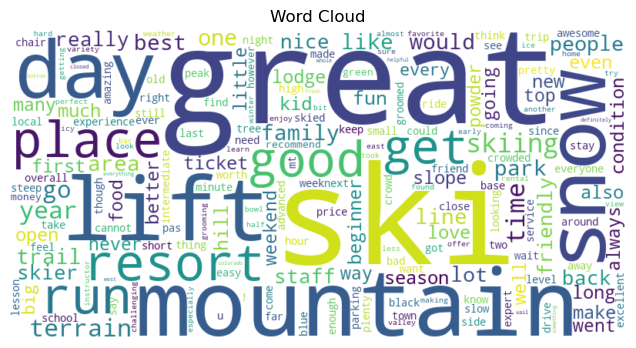

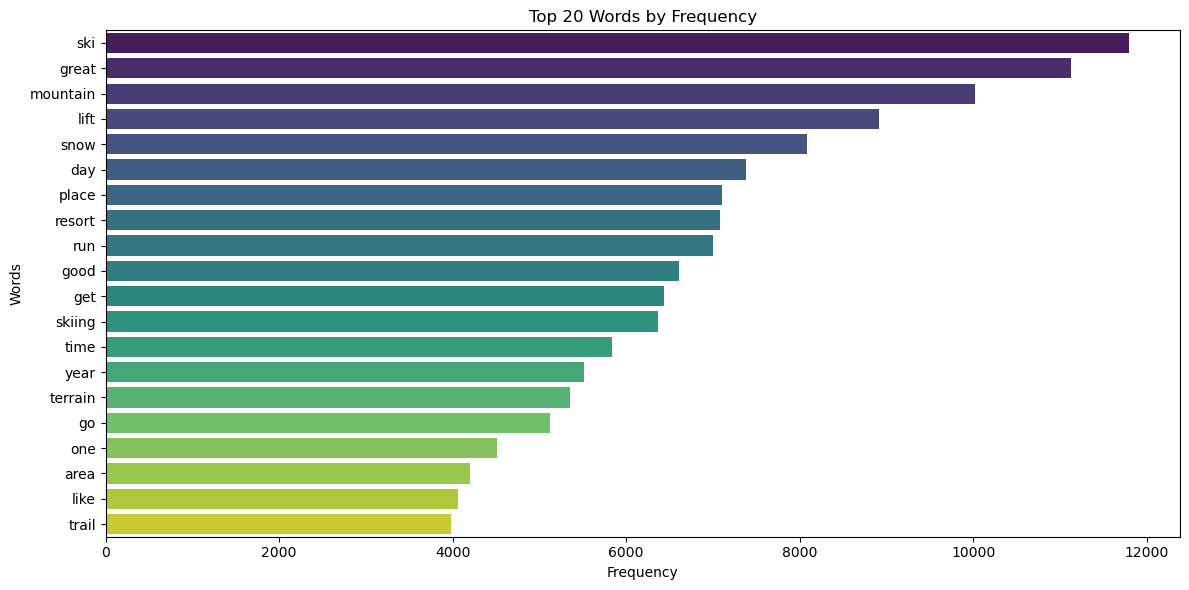

In [8]:
def generate_word_cloud(df, text_column="lemmatized",
                        width=800, height=400,
                        background_color='white',
                        colormap='viridis',
                        max_words=200,
                        contour_color='black',
                        contour_width=1):
    """
    Generates and displays a word cloud from the processed text data.
    Also creates a horizontal bar chart for the top 20 words.
    """
    word_counts = Counter()

    # Extract and count words
    for tokens in df[text_column].dropna():
        if isinstance(tokens, list):
            word_counts.update(word for word in tokens if isinstance(word, str))
        elif isinstance(tokens, str):
            word_counts.update(tokens.split())
        else:
            print(f"Warning: Skipping unexpected data type {type(tokens)} in '{text_column}'.")

    if not word_counts:
        print("No valid words found to generate a word cloud.")
        return None, {}

    # Generate word cloud
    wordcloud = WordCloud(
        width=width,
        height=height,
        background_color=background_color,
        colormap=colormap,
        max_words=max_words,
        contour_color=contour_color,
        contour_width=contour_width
    ).generate_from_frequencies(word_counts)

    # Display the word cloud
    plt.figure(figsize=(width / 100, height / 100))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title("Word Cloud")
    plt.show()

    # Horizontal Bar Chart for Top 20 Words
    top_words = word_counts.most_common(20)
    top_df = pd.DataFrame(top_words, columns=["words", "freqs"])

    plt.figure(figsize=(12, 6))
    ax = sns.barplot(data=top_df, x="freqs", y="words", hue="words", palette="viridis", dodge=False)
    if ax.get_legend():
        ax.legend_.remove()
    plt.xlabel("Frequency")
    plt.ylabel("Words")
    plt.title("Top 20 Words by Frequency")
    plt.tight_layout()
    plt.show()

    return wordcloud, word_counts

wc, word_frequencies = generate_word_cloud(df_clean)

### Step 8: Word Cloud Visualization  
**Final Check Before Moving Forward:**

After inspecting the word cloud and frequent words, briefly answer:

1. Do these high-frequency words reflect what you would expect for a dataset of ski resort reviews?
2. Do these frequent words indicate clear differences between the target classes?

**Briefly justify** whether the word distribution confirms the dataset is appropriate for building a text classification model, or explain if further cleaning is needed.

---

### Answer

1. Yes, the high-frequency words such as **“ski”**, **“mountain”**, **“lift”**, **“snow”**, **“resort”**, and **“terrain”** are exactly what one would expect in ski resort reviews. These terms capture essential aspects of the skiing experience and indicate that the content is domain-relevant.

2. Not directly. While the words are relevant, they are largely descriptive of the general ski experience and do not clearly separate different review categories (e.g., positive vs. negative, beginner vs. expert, family-friendly vs. advanced). Additional analysis (e.g., class-specific word frequencies or sentiment analysis) may be needed to identify discriminative features.

**Justification**  
The word distribution confirms that the dataset is highly relevant for ski resort reviews and appropriate for text classification. While the top words provide good coverage of domain-specific terms, further steps may be required to uncover features that distinguish between the target classes. No additional cleaning is needed at this point, but feature refinement could improve classification performance.

## Step 9: Exporting the Cleaned Reviews Without Sentiment Labels

### Overview  
This step exports the final cleaned dataset to a `.csv` file, preserving each review’s original numeric star rating (1–5) without assigning it a binary sentiment label. The cleaned text is saved in a format that makes it compatible with downstream tools and further analysis.

### What This Step Does:

1. **Convert Ratings to Numeric:**  
   The `Review Star Rating (out of 5)` column is converted to a numeric type. Any non-numeric or invalid values are coerced to `NaN`.

2. **Remove Invalid Rows:**  
   Reviews without a valid numeric rating are dropped from the dataset to ensure consistency and avoid issues in later analysis.

3. **Prepare Cleaned Text for Export:**  
   The `lemmatized` column—containing lists of cleaned tokens—is joined into plain strings for each review.

4. **Export to CSV:**  
   A new CSV file is created with two columns:
   - `Review Star Rating (out of 5)` – the original numeric rating from 1 to 5  
   - `cleaned_text_str` – the fully preprocessed review as a plain string  

   The output file is saved using the same base name as the original dataset, with `_CLEANED` added to indicate it has been preprocessed.

### Output:
- `OnTheSnow_SkiAreaReviews_CLEANED.csv`  
  This file contains one row per review, with its numeric star rating and cleaned text string.

In [9]:
# 1) Convert Rating to a numeric type
df_clean["Review Star Rating (out of 5)"] = pd.to_numeric(df_clean["Review Star Rating (out of 5)"], errors="coerce")

# 2) Drop rows that do not have a valid numeric rating
df_clean = df_clean.dropna(subset=["Review Star Rating (out of 5)"])

def export_cleaned_text(
    df,
    text_column="lemmatized",
    rating_column="Review Star Rating (out of 5)",
    output_file=None
):
    """
    Exports two columns to CSV:
      1) rating_column (the original numeric rating)
      2) cleaned_text_str (the cleaned text joined by spaces)
    """
    import os

    if output_file is None:
        base_name, ext = os.path.splitext(DATASET_FILE)
        output_file = f"{base_name}{OUTPUT_SUFFIX}{ext}"

    df = df.copy()

    # Join tokens to a single string
    df["cleaned_text_str"] = df[text_column].apply(
        lambda tokens: " ".join(tokens) if isinstance(tokens, list) else str(tokens)
    )

    out_df = df[[rating_column, "cleaned_text_str"]]
    out_df.to_csv(output_file, index=False, encoding="utf-8")

    print(f"\nCleaned text and numeric rating have been exported to '{output_file}'.")


# 3) Call the export function without sentiment binning
export_cleaned_text(
    df_clean,
    text_column="lemmatized",
    rating_column="Review Star Rating (out of 5)",
    output_file=None
)

print("\nStep 9 completed: Data exported without positive/negative labels!")



Cleaned text and numeric rating have been exported to 'OnTheSnow_SkiAreaReviews_CLEANED.csv'.

Step 9 completed: Data exported without positive/negative labels!


## Step 10: Exporting the Cleaned Reviews with Binary Labels

### Overview  
In this step, the cleaned dataset is prepared for binary text classification by converting the original 5-star ratings into sentiment-based binary labels. This format is especially useful for supervised learning models that aim to classify reviews as either positive or negative.

### What This Step Does:

1. **Convert Star Ratings to Binary Labels:**  
   - Ratings **3 and above** are labeled as **`1`** (positive)  
   - Ratings **below 3** are labeled as **`0`** (negative)  

   This binarization simplifies the classification task and aligns with common sentiment analysis practices.

2. **Join Cleaned Tokens:**  
   - The `lemmatized` column, which contains tokenized and preprocessed reviews, is converted into a plain string for each review.  
   - Each cleaned review appears as a space-separated sentence in a new column: `cleaned_text_str`.

3. **Export to a Binary-Labeled CSV File:**  
   - The final output includes:
     - A binary label (`0` or `1`)  
     - The cleaned review text (`cleaned_text_str`)  
   - The CSV file is automatically named with a `_BINARY` suffix for clarity.

### Output:
- `OnTheSnow_SkiAreaReviews_BINARY.csv`  
  A ready-to-use dataset for binary classification, with one row per review containing:
  - A sentiment label  
  - Cleaned, lemmatized review text 

In [10]:
def export_cleaned_text_binarized_appendix(
    df,
    text_column="lemmatized",
    rating_column="Review Star Rating (out of 5)",
    output_file=None
):
    """
    Exports two columns to CSV:
      1) Rating (converted to binary: 1 for ratings 3 and above, 0 for below 3)
      2) cleaned_text_str (the cleaned text joined by spaces)
    If output_file is not provided, the file will be created with a '_BINARY' suffix appended to the original file name.
    """
    import os

    # If output_file is not provided, create one with the '_BINARY' suffix.
    if output_file is None:
        base_name, ext = os.path.splitext(DATASET_FILE)
        output_file = f"{base_name}_BINARY{ext}"

    df = df.copy()

    # Convert the original rating column to binary values.
    df[rating_column] = df[rating_column].apply(lambda x: 1 if x >= 3.0 else 0)

    # Join tokens into a single string for the cleaned text.
    df["cleaned_text_str"] = df[text_column].apply(
        lambda tokens: " ".join(tokens) if isinstance(tokens, list) else str(tokens)
    )

    # Create a new DataFrame with the binary rating and the cleaned text.
    out_df = df[[rating_column, "cleaned_text_str"]]
    out_df.to_csv(output_file, index=False, encoding="utf-8")

    print(f"\nCleaned text and binary rating have been exported to '{output_file}' (with '_BINARY' appendix).")


# Call the function with your cleaned DataFrame
export_cleaned_text_binarized_appendix(
    df_clean,
    text_column="lemmatized",
    rating_column="Review Star Rating (out of 5)",
    output_file=None
)

print("\nStep 10 completed: Data exported with binary positive/negative labels in a new file!")



Cleaned text and binary rating have been exported to 'OnTheSnow_SkiAreaReviews_BINARY.csv' (with '_BINARY' appendix).

Step 10 completed: Data exported with binary positive/negative labels in a new file!


### Why I Changed the Binary Classification Threshold

I updated the binary classification rule so that:

- **Ratings of 3, 4, and 5 are labeled as `1` (positive)**  
- **Ratings of 1 and 2 are labeled as `0` (negative)**

This decision reflects a more **balanced and realistic interpretation of user sentiment** in ski resort reviews. A rating of **3 stars is typically considered neutral-to-positive**, indicating that the user had a generally acceptable or mildly favorable experience. Including 3-star reviews in the positive class helps:

- Increase the number of positive samples for training  
- Avoid misclassifying neutral opinions as negative 
- Align better with real-world user behavior, where 3-star reviews are not necessarily negative

This threshold helps the model focus on identifying **clearly satisfied vs. clearly dissatisfied** customers.


## Step 11: Final Dataset Preview

### Overview  
Before proceeding to text classification, it is essential to verify that the final datasets are properly cleaned, correctly labeled, and ready for modeling. This step offers a **last visual inspection** to confirm that all preprocessing has been applied successfully and that the format is suitable for both multi-class and binary classification tasks.

### What This Step Does:

- **Displays a preview of the final cleaned datasets** that were saved in previous steps:
  - `OnTheSnow_SkiAreaReviews_CLEANED.csv`: Contains full numeric star ratings (1–5) and cleaned review text.
  - `OnTheSnow_SkiAreaReviews_BINARY.csv`: Contains binary sentiment labels (`1` for 3–5 stars, `0` for 1–2 stars) and cleaned review text.
- **Samples 5 random entries** from each dataset to visually confirm:
  - That the `cleaned_text_str` column contains well-formatted, preprocessed, lemmatized text.
  - That star ratings or binary labels are consistent with the corresponding review content.

### Why This Is Important:

- Helps validate that the cleaned data is free from errors, missing values, or formatting issues.
- Ensures that the binary label logic was applied correctly during export (Step 10).
- Provides a sanity check before feeding the data into machine learning models.
- Confirms that each review is properly aligned with its target label, which is critical for effective training and evaluation.

After this step, both datasets can be confidently used for building and evaluating classification models.

In [11]:
import pandas as pd

# Load the cleaned datasets
df_cleaned = pd.read_csv("OnTheSnow_SkiAreaReviews_CLEANED.csv")
df_binary = pd.read_csv("OnTheSnow_SkiAreaReviews_BINARY.csv")

# Display samples from each
print("Preview: Cleaned Dataset (Multi-Class Labels)")
display(df_cleaned[['cleaned_text_str', 'Review Star Rating (out of 5)']].sample(5, random_state=42))

print("\nPreview: Binary Classification Dataset")
display(df_binary[['cleaned_text_str', 'Review Star Rating (out of 5)']].sample(5, random_state=42))

Preview: Cleaned Dataset (Multi-Class Labels)


,cleaned_text_str,Review Star Rating (out of 5)
6096,wow blue black harder keystone vail copper?? u...,5
6834,solid local place friendly,3
6281,easy get nice large family dining great rain b...,5
11631,snow tube slope assured open 12pm arrived prom...,1
4533,money know better snow ever seen terrain excel...,5



Preview: Binary Classification Dataset


,cleaned_text_str,Review Star Rating (out of 5)
6096,wow blue black harder keystone vail copper?? u...,1
6834,solid local place friendly,1
6281,easy get nice large family dining great rain b...,1
11631,snow tube slope assured open 12pm arrived prom...,0
4533,money know better snow ever seen terrain excel...,1


### Why This Dataset Is Now Suitable for Text Classification

The ski resort review dataset has undergone comprehensive preprocessing to ensure it is clean, structured, and ready for binary text classification. Here's a summary of the key steps taken:

- **Text Cleaning**: Removed punctuation, stray characters, and inconsistencies to normalize the text.
- **Tokenization and Lemmatization**: Broke reviews into word-level tokens and reduced each word to its base (dictionary) form, improving consistency.
- **Stopword Removal**: Eliminated common, low-value words (e.g., "and", "the", "was") that do not help distinguish between classes.
- **Length-Based Outlier Filtering**: Removed unusually short or long reviews using the 5th and 95th percentile as dynamic thresholds. This helped reduce both noise and class imbalance.
- **Label Conversion for Sentiment Classification**: Transformed the original 1–5 star ratings into a **binary label**:
  - Ratings of **3, 4, or 5 stars** are labeled as **1 (positive sentiment)**
  - Ratings of **1 or 2 stars** are labeled as **0 (negative sentiment)**

### Final Output

Two CSV files were generated:
- `OnTheSnow_SkiAreaReviews_CLEANED.csv` — Cleaned reviews with original numeric ratings.
- `OnTheSnow_SkiAreaReviews_BINARY.csv` — Cleaned reviews with binary sentiment labels for classification.

The `cleaned_text_str` column in both files contains the final processed version of each review, formatted as a plain string and ready for vectorization.

---

With irrelevant content removed, the text simplified, and the labels clearly defined, this dataset is now **well-suited for training a robust binary sentiment classification model**. This is a crucial step toward helping **Batawa Ski Hill** better understand guest satisfaction trends and tailor services to improve the visitor experience.

